In [2]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load the dataset first
titanic = pd.read_csv("Titanic-Cleaned.csv")

# Label Encode Sex
titanic['Sex_encoded'] = LabelEncoder().fit_transform(titanic['Sex'])

# One-Hot Encode Embarked
titanic = pd.get_dummies(titanic, columns=['Embarked'], prefix='Embarked')

Used LabelEncoder for Sex since it has only two categories (male/female).

Used OneHotEncoder for Embarked since it has 3+ categories (C, Q, S).

In [3]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

# Standardized
scaled_std = scaler_std.fit_transform(titanic[['Age','Fare']])

# MinMax
scaled_mm = scaler_mm.fit_transform(titanic[['Age','Fare']])

by applying StandardScaler - mean = 0, std = 1.

by applying MinMaxScaler - values scaled to [0,1].

In [4]:
Q1 = titanic['Fare'].quantile(0.25)
Q3 = titanic['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = titanic[(titanic['Fare'] < lower) | (titanic['Fare'] > upper)]

Q1 = 25th percentile (the value below which 25% of fares fall).

Q3 = 75th percentile (the value below which 75% of fares fall).

These give you the spread of the middle 50% of the data.

Larger IQR - more variability in ticket prices.

Anything below lower or above upper is considered an outlier.

The multiplier 1.5 is a standard rule of thumb in statistics for detecting outliers.

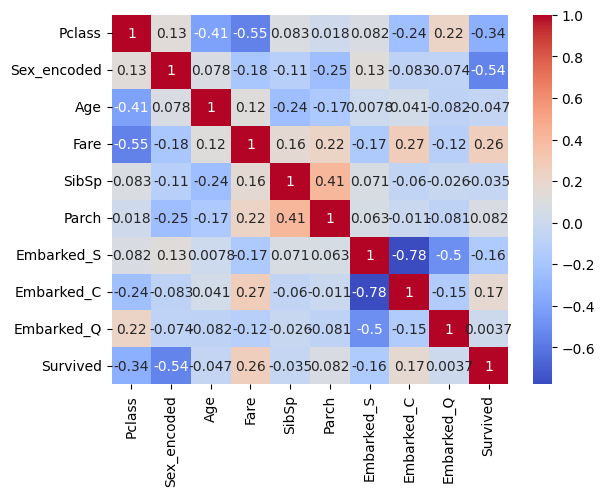

Selected features: Index(['Pclass', 'Sex_encoded', 'Fare', 'Embarked_S', 'Embarked_C'], dtype='object')


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif

# Keep only numeric + encoded categorical features
X = titanic[['Pclass','Sex_encoded','Age','Fare','SibSp','Parch',
             'Embarked_S','Embarked_C','Embarked_Q']]
y = titanic['Survived']

# 1. Correlation Heatmap
corr = X.join(y).corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# 2. Feature Selection with SelectKBest
selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)
selected = X.columns[selector.get_support()]
print("Selected features:", selected)


SelectKBest + f_classif
- statistical method to select the most predictive features.

X = all numeric + encoded categorical features.

y = target column (Survived).

I drop text columns (Name, Ticket, Cabin, Port) because they can’t be converted to numbers.

corr calculates pairwise correlations between features and survival.

SelectKBest applies an ANOVA F-test to measure how well each feature separates survivors vs non-survivors.

The ANOVA F-test (Analysis of Variance F-test) is a statistical method used to check whether a feature (independent variable) has a significant relationship with the target (dependent variable).

k=5 means we keep the top 5 features.

selector.get_support() returns a mask of the chosen features.

selected prints the actual column names.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

from sklearn.model_selection import train_test_split
- This function splits the dataset into training and testing sets.

X[selected]
- only the features chosen in Step 2d

y - the target column (Survived)

test_size=0.2
- 20% of the data goes into the test set.

stratify=y
- ensures the survival ratio is preserved in both train and test sets.

random_state=42
- fixes the random seed so results are reproducible.

Without stratification, we can get a test set with too many survivors or too few survivors.

Stratification keeps the class distribution consistent and makes the model evaluation reliable.